In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1. Load Dataset
data = pd.read_csv("dataset/breast-cancer.csv")

print("Dataset:")
print(data.head())

print("\nDataset Shape:", data.shape)


Dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst 

In [3]:
# 2. Separate Features and Target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("\nFeatures:")
print(X.columns)

print("\nOutput Class:", y.name)


Features:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='str')

Output Class: fractal_dimension_worst


In [4]:
# 3. Split Dataset
X = data.drop(columns=["id", "diagnosis"])
y = data["diagnosis"].map({"B": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
# 4. Different Numbers of Trees
tree_values = [10, 50, 100, 150, 200]

results = []

In [6]:
# 5. Train Random Forest for Different Tree Values
for trees in tree_values:

    model = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([trees, accuracy])

    print("\nNumber of Trees:", trees)
    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Number of Trees: 10
Accuracy: 96.49 %

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


Number of Trees: 50
Accuracy: 97.37 %

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Number of Trees: 100
Accuracy: 97.37 %

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96    

In [7]:
# 6. Create Comparison Table
results_df = pd.DataFrame(
    results,
    columns=["Number of Trees", "Accuracy"]
)

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100

print("Random Forest Performance: \n")

print(results_df[["Number of Trees", "Accuracy (%)"]])

Random Forest Performance: 

   Number of Trees  Accuracy (%)
0               10     96.491228
1               50     97.368421
2              100     97.368421
3              150     96.491228
4              200     96.491228


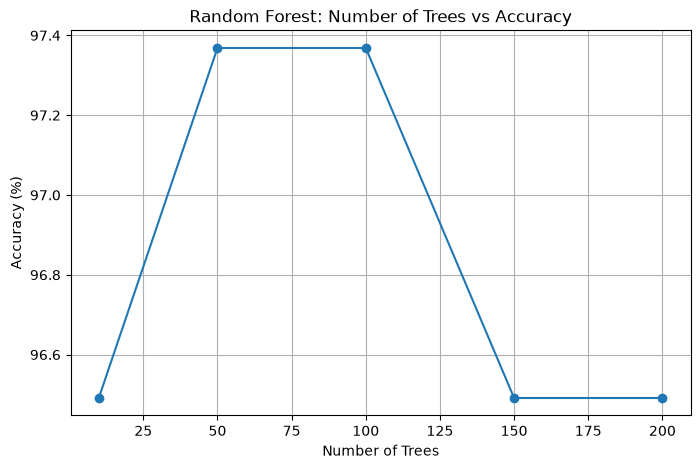

In [8]:
# 7. Plot Number of Trees vs Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Number of Trees"],
    results_df["Accuracy (%)"],
    marker="o"
    
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy (%)")
plt.title("Random Forest: Number of Trees vs Accuracy")

plt.grid(True)
plt.show()